# Problem 1

#### 1.

To satisfy $\mathbb{Z}_2$-symmetry, we feed only even features into our model: 

$$  h_\theta(x) =g_\theta (x^2) $$

where $ g_\theta$ is a standard neural network (in our case a multi-layer perceptron implemented using sklearn).

Proof: $$h_\theta(-x)=g_\theta((-x)^2)=g_\theta(x^2)=h_\theta(x)$$.


#### 2.

We now sample data from two even functions, a Gaussian and Cosine respectively:


In [1]:
import numpy as np
import pylab as plt 
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
def test_z2_symmetry(x_train, y_train, x_test, y_test):
    a=(20,20,20,10,5)  # architecture
    mlp_base = MLPRegressor(hidden_layer_sizes=a, activation='relu', solver='adam', alpha=1e-4, max_iter=4000, random_state=12)
    mlp_z2 = MLPRegressor(hidden_layer_sizes=a, activation='relu', solver='adam', alpha=1e-4, max_iter=4000, random_state=2)

    # Baseline: feed x directly
    mlp_base.fit(x_train.reshape(-1, 1), y_train)

    # Z2-symmetric: feed x² to enforce symmetry around x=0
    mlp_z2.fit((x_train**2).reshape(-1, 1), y_train)

    base_pred = mlp_base.predict(x_test.reshape(-1, 1))
    z2_pred   = mlp_z2.predict((x_test**2).reshape(-1, 1))

    mse_base_full = mean_squared_error(y_test, base_pred)
    mse_z2_full   = mean_squared_error(y_test, z2_pred)
    return mse_base_full, mse_z2_full , base_pred, z2_pred

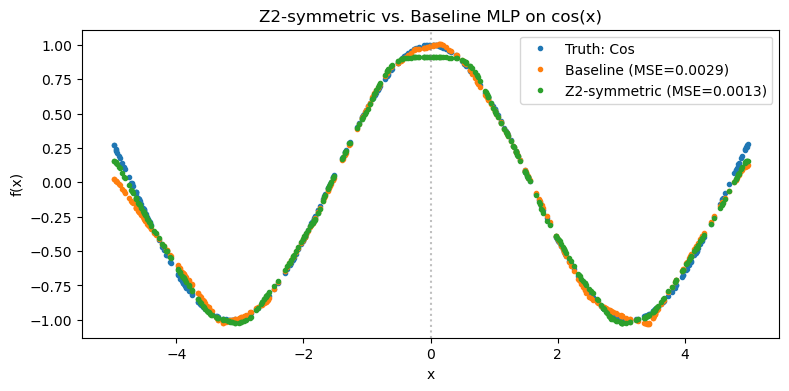

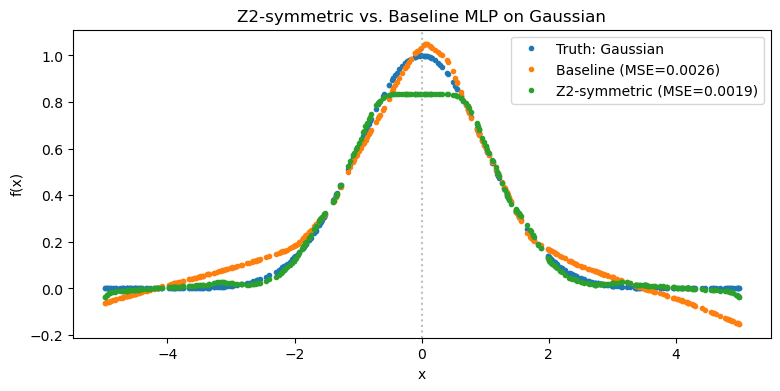

In [2]:



# Generate toy training and test data for cos(x)
rng = np.random.default_rng(42)
x_train = rng.uniform(-5, 5, 400)        
y_train = np.cos(x_train) 

x_test = rng.uniform(-5, 5, 400)
y_test = np.cos(x_test)  
mse_base_full_cos, mse_z2_full_cos, base_pred_cos, z2_pred_cos = test_z2_symmetry(x_train, y_train, x_test, y_test)



# Plot to visualize cos(x)
plt.figure(figsize=(9, 4))
plt.plot(x_test, y_test, '.', label='Truth: Cos')
plt.plot(x_test, base_pred_cos, '.', label=f'Baseline (MSE={mse_base_full_cos:.4f})')
plt.plot(x_test, z2_pred_cos, '.', label=f'Z2-symmetric (MSE={mse_z2_full_cos:.4f})')
plt.axvline(0, color='gray', ls=':', alpha=0.5)

plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Z2-symmetric vs. Baseline MLP on cos(x)')
plt.show()

# Generate toy training and test data for a gaussian:
rng = np.random.default_rng(42)
x_train = rng.uniform(-5, 5, 400)       
y_train = np.exp(-0.5 * x_train**2)
x_test = rng.uniform(-5, 5, 400)
y_test = np.exp(-0.5 * x_test**2) 
mse_base_full_gauss, mse_z2_full_gauss, base_pred_gauss, z2_pred_gauss = test_z2_symmetry(x_train, y_train, x_test, y_test) 

plt.figure(figsize=(9, 4))
plt.plot(x_test, y_test, '.', label='Truth: Gaussian')
plt.plot(x_test, base_pred_gauss, '.', label=f'Baseline (MSE={mse_base_full_gauss:.4f})')
plt.plot(x_test, z2_pred_gauss, '.', label=f'Z2-symmetric (MSE={mse_z2_full_gauss:.4f})')
plt.axvline(0, color='gray', ls=':', alpha=0.5)

plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Z2-symmetric vs. Baseline MLP on Gaussian')
plt.show()



For both even functions we see that by introducing the Z2-symmetry, the model performs better.  We find, interestingly, that the model has a harder time to predict the data around $x = \pm 0.5$. If we had chosen the training data to only sample from x>0, we would see the baseline model fail terribly in the region $x<0$, as we see below:

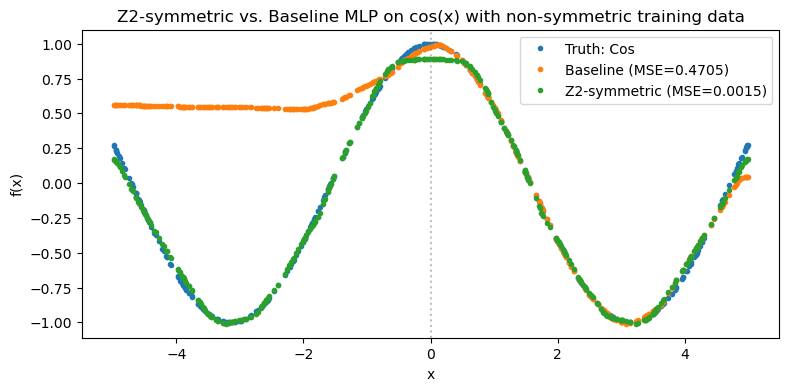

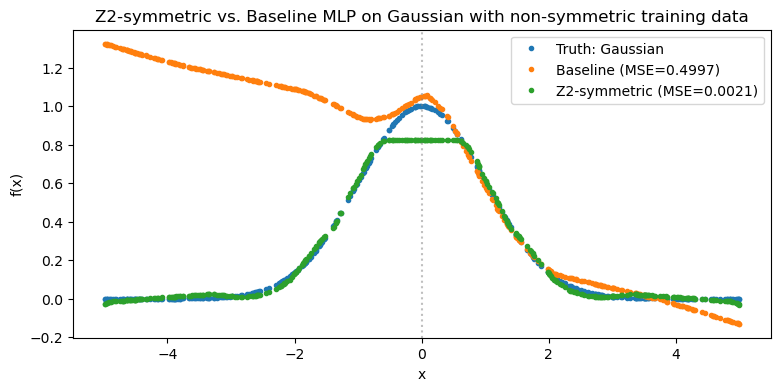

In [3]:



# Generate toy training and test data for cos(x)
rng = np.random.default_rng(42)
x_train = rng.uniform(0, 5, 400)        
y_train = np.cos(x_train) 

x_test = rng.uniform(-5, 5, 400)
y_test = np.cos(x_test)  
mse_base_full_cos, mse_z2_full_cos, base_pred_cos, z2_pred_cos = test_z2_symmetry(x_train, y_train, x_test, y_test)



# Plot to visualize cos(x)
plt.figure(figsize=(9, 4))
plt.plot(x_test, y_test, '.', label='Truth: Cos')
plt.plot(x_test, base_pred_cos, '.', label=f'Baseline (MSE={mse_base_full_cos:.4f})')
plt.plot(x_test, z2_pred_cos, '.', label=f'Z2-symmetric (MSE={mse_z2_full_cos:.4f})')
plt.axvline(0, color='gray', ls=':', alpha=0.5)

plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Z2-symmetric vs. Baseline MLP on cos(x) with non-symmetric training data')
plt.show()

# Generate toy training and test data for a gaussian:
rng = np.random.default_rng(42)
x_train = rng.uniform(0, 5, 400)       
y_train = np.exp(-0.5 * x_train**2)
x_test = rng.uniform(-5, 5, 400)
y_test = np.exp(-0.5 * x_test**2) 
mse_base_full_gauss, mse_z2_full_gauss, base_pred_gauss, z2_pred_gauss = test_z2_symmetry(x_train, y_train, x_test, y_test) 

plt.figure(figsize=(9, 4))
plt.plot(x_test, y_test, '.', label='Truth: Gaussian')
plt.plot(x_test, base_pred_gauss, '.', label=f'Baseline (MSE={mse_base_full_gauss:.4f})')
plt.plot(x_test, z2_pred_gauss, '.', label=f'Z2-symmetric (MSE={mse_z2_full_gauss:.4f})')
plt.axvline(0, color='gray', ls=':', alpha=0.5)

plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Z2-symmetric vs. Baseline MLP on Gaussian with non-symmetric training data')
plt.show()



# Problem 2

## Part 1a
The data set that we will use is a turbulent radiative layer in 2D with four scalar fields at every time step. The four fields are:
0	density
1	pressure
2	velocity_x (horizontal component)
3	velocity_y (vertical component)  

The system is brought to its initial conditions after every 100 frames.
The initial conditions are:
The density is large and uniform up to x=150 and 0 for x>150. 

Pressure is uniform throughout the space.

The Velocity in the y direction is randomized from initialisation to initialisation and so is velocity in x, except all mass in the high density region moves in negative x-direction.    

As for boundary conditions, the boundary tensor reads [[2,2],[1,1]] which is a statement that the system is open in the x-direction, while there are periodic boundary conditions in the y-direction for the density field. 
First let's import, split and visualize the data by borrowing the scripts from "Example of using TheWell.ipynb" by Clark Miyamoto:  

In [4]:
BASE_PATH = './datasets'
DATASET = 'turbulent_radiative_layer_2D'
SPLIT = 'train'

In [5]:
import the_well
from the_well.data import WellDataset
from the_well.utils.download import well_download
import matplotlib.pyplot as plt

In [6]:
# Takes a long time, modify your script so you only run this once.
well_download(base_path=BASE_PATH, dataset=DATASET, split=SPLIT)

In [7]:
dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name=SPLIT,
)
print(type(dataset))

<class 'the_well.data.datasets.WellDataset'>


In [8]:
len(dataset)

7200

In [9]:
dataset[0].keys()

dict_keys(['input_fields', 'output_fields', 'constant_scalars', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid'])

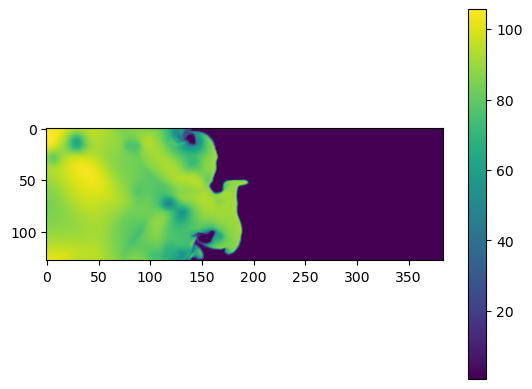

Bound. cond.:  
 tensor([[2., 2.],
        [1., 1.]])
Input fields shape: torch.Size([1, 128, 384, 4])


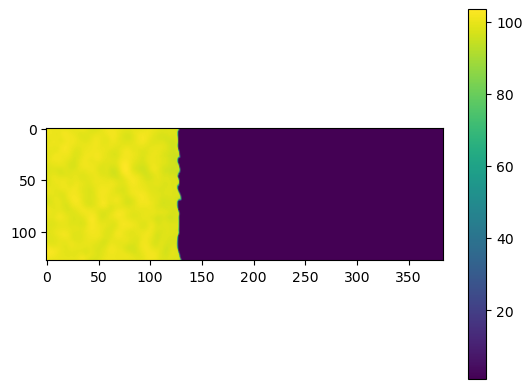

Bound. cond.:  
 tensor([[2., 2.],
        [1., 1.]])
Input fields shape: torch.Size([1, 128, 384, 4])


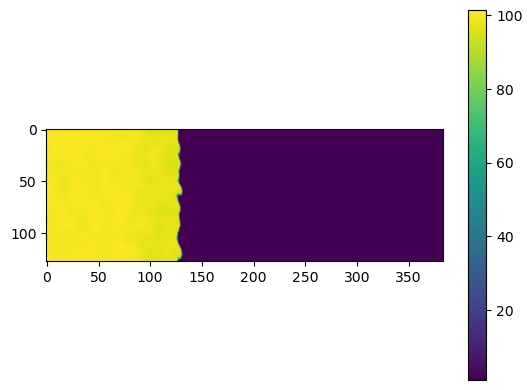

Bound. cond.:  
 tensor([[2., 2.],
        [1., 1.]])
Input fields shape: torch.Size([1, 128, 384, 4])


In [10]:
for i in range(3):
    # Add a colorbar. 
    idx = 99+i
    channel_id = 0
    plt.imshow(dataset[idx]['output_fields'][0][:,:,channel_id])
    plt.colorbar()
    plt.show()
    print('Bound. cond.:  \n '+str(dataset[idx]['boundary_conditions']))
    print('Input fields shape:', dataset[idx]['input_fields'].shape)

In [11]:
dataset[0]['boundary_conditions']

tensor([[2., 2.],
        [1., 1.]])

In [12]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from ipywidgets import interact, IntSlider

def visualize_dataset(idx):
    # Retrieve the data for the selected index
    # Assuming 'input_fields' shape is (frames, height, width, channels)
    data = dataset[idx]['input_fields'][0]

    fig, ax = plt.subplots()
    im = ax.imshow(data[:, :, 0])
    ax.set_title(f"Dataset Index: {idx} | Channel: 0")

    def update(channel_id):
        # Update image data for each frame of the animation
        im.set_data(data[:, :, channel_id])
        ax.set_title(f"Dataset Index: {idx} | Channel: {channel_id}")
        return [im]

    # Create animation: frames = number of channels/time steps
    num_channels = data.shape[-1]
    ani = FuncAnimation(fig, update, frames=range(num_channels),
                        interval=200, blit=True)

    plt.show()

# Create the interactive slider
interact(visualize_dataset, idx=IntSlider(min=0, max=len(dataset)-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='idx', max=7199), Output()), _dom_classes=('widget-intera…

<function __main__.visualize_dataset(idx)>

## Part 1b

The symmetry that we will enforce is translational equivariance in the y-direction, since translating in the y-direction shouldn't change the physics. Even when translating past the top and bottom boundary, the density simply wraps around. This is not the case in the x-direction, where the boundaries are open.  

## Part 2a
For our architecture we have connectivity at each layer of the neural network that enforces this translational equivariance. Let's set up the network so that the nodes in each layer connects to (second) nearest neighbor (CNN), with the exception of the nodes closest to the top (bottom) edge - those a connected to the bottom (top) nodes too. In other words, in the y-direction, the convolution wraps around, while in x it uses standard zero-padding.  

## Part 2b

We now proceed to the proof (Help from Goodfellow et al. 2016, ch. 9 and LLM Model Claude):
Claim: Let $\bold{Z}_{N_y}$ be the cyclic group of order $N_y$ (the number of pixels in the y-directions), then a CNN with circular padding in y is $G$-equivariant for $G=\bold{Z}_{N_y}$ that is, $f(\rho(t_k)x)=\rho(t_k)f(x)$ for all $g=t_k \in G.$

For a shift $g$ both input and ouput representations act identically: 

$$ [\rho_{in}(t_k)x]_{i,j}=x_{i,(j-k)\mod N_y}$$
$$ \rho_{in}=\rho_{out} $$

A convulutional layer with circular padding in $y$ computes:

$$ [f(x)]_{i,j}=\sigma(\sum_{a,b}w_{a,b}x_{i+a,(j+b)\mod N_y} + \beta) $$

Here $a$ and $b$ are bounded so that we preserve connectivity to nearest neighbors and the cyclic padding is implemented through $(j+b)\mod N_y$ on the y-index. 

Proof: 
$$ [f(\rho_{in}(t_k)x)]_{i,j}=\sigma(\sum_{a,b}w_{a,b}[\rho_{in}(t_k)x]_{i+a,(j+b)\mod N_y}+\beta) $$

$$ [f(\rho_{in}(t_k)x)]_{i,j}=\sigma(\sum_{a,b}w_{a,b}x_{i+a,(j-k+b)\mod N_y}+\beta) $$

$$[f(\rho_{in}(t_k)x)]_{i,j}= [f(x)]_{i,(j−k)\mod N_y}$$

Meanwhile:

$$ [\rho_{out}(t_k)f(x)]_{i,j}=[f(x)]_{i,(j−k)\mod N_y} $$

$$\implies [\rho_{out}(t_k)f(x)]_{i,j}=[f(\rho_{in}(t_k)x)]_{i,j} \blacksquare $$


## Part 3a
We now proceed with the implementation of this translational equivariance. To prepare the data, we normalize the data so that the weights are fair accross all channels. 

In [13]:
# ALL IMPORTS, DEF. OF FUNCTIONS AND CLASSES
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import pylab as plt 
from the_well.data import WellDataset
from the_well.utils.download import well_download


In [ ]:

# --- Custom Layers ---
class CircPadConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        self.pad = kernel_size // 2
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, padding=0)

    def forward(self, x):
        x = F.pad(x, (self.pad, self.pad, 0, 0), mode='constant', value=0)
        x = F.pad(x, (0, 0, self.pad, self.pad), mode='circular')
        return self.conv(x)

# --- CNN Model ---
class CircPadCNN(nn.Module):
    def __init__(self, in_ch=16, out_ch=4):
        super().__init__()
        kernel_s = 5
        self.conv1 = CircPadConv2d(in_ch, 32, kernel_size=kernel_s)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = CircPadConv2d(32, 64, kernel_size=kernel_s)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = CircPadConv2d(64, 32, kernel_size=kernel_s)
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = CircPadConv2d(32, 16, kernel_size=kernel_s)
        self.bn4 = nn.BatchNorm2d(16)
        self.conv5 = CircPadConv2d(16, out_ch, kernel_size=kernel_s)

    def forward(self, x):
        last_frame = x[:, -4:, :, :]
        x1 = F.relu(self.bn1(self.conv1(x)))
        x2 = F.relu(self.bn2(self.conv2(x1)))
        x3 = F.relu(self.bn3(self.conv3(x2)))
        x4 = F.relu(self.bn4(self.conv4(x3)))
        correction = self.conv5(x4)
        return last_frame + correction

# --- Loss ---
def gradient_loss(pred, target):
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    return ((pred_dx - target_dx).abs().mean() + (pred_dy - target_dy).abs().mean())

# --- Data Preparation (memory-friendly) ---
def prepare_data(dataset, init, final, n_frames=4):
    x = []
    y = []
    for i in range(init, final - n_frames + 1):
        frames = []
        for j in range(n_frames):
            frames.append(dataset[i + j]['input_fields'][0][:, :, :].permute(2, 0, 1))
        stacked = torch.cat(frames, dim=0)
        x.append(stacked)
        y.append(dataset[i + n_frames - 1]['output_fields'][0][:, :, :].permute(2, 0, 1))
    return torch.stack(x).float(), torch.stack(y).float()

# --- Zero Padding Conv Layer (standard) ---
class ZeroPadConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, padding=kernel_size // 2)

    def forward(self, x):
        return self.conv(x)

# --- Regular CNN (zero padding everywhere) ---
class RegularCNN(nn.Module):
    def __init__(self, in_ch=16, out_ch=4):
        super().__init__()
        kernel_s = 5
        self.conv1 = ZeroPadConv2d(in_ch, 32, kernel_size=kernel_s)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = ZeroPadConv2d(32, 64, kernel_size=kernel_s)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = ZeroPadConv2d(64, 32, kernel_size=kernel_s)
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = ZeroPadConv2d(32, 16, kernel_size=kernel_s)
        self.bn4 = nn.BatchNorm2d(16)
        self.conv5 = ZeroPadConv2d(16, out_ch, kernel_size=kernel_s)

    def forward(self, x):
        last_frame = x[:, -4:, :, :]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        correction = self.conv5(x)
        return last_frame + correction


print("All classes and functions defined.")
print(f"CUDA available: {torch.cuda.is_available()}")
#if torch.cuda.is_available():
#    print(f"GPU: {torch.cuda.get_device_name(0)}")

All classes and functions defined.
CUDA available: True


In [16]:
from neuralop.models import FNO

class ResidualFNO(nn.Module):
    def __init__(self):
        super().__init__()
        self.fno = FNO(
            n_modes=(12, 12),
            in_channels=16,
            out_channels=4,
            hidden_channels=64,
            n_layers=4,
            domain_padding=0.0,
        )

    def forward(self, x):
        last_frame = x[:, -4:, :, :]
        correction = self.fno(x)
        return last_frame + correction

print("FNO model defined.")

FNO model defined.


In [17]:
BASE_PATH = './datasets'
DATASET = 'turbulent_radiative_layer_2D'
SPLIT = 'train'

well_download(base_path=BASE_PATH, dataset=DATASET, split=SPLIT)
dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name=SPLIT,
)
print(type(dataset))



<class 'the_well.data.datasets.WellDataset'>


In [37]:
# To compare the two models, we will train both the CircPadCNN and the ResidualFNO on the same normalized dataset and evaluate their performance on the test set. We will use VRMSE (Variance-Reduced Mean Squared Error) as our evaluation metric. We also keep all other hyperparameters the same for a fair comparison:
n_epochs = 12
Ntrain = 600

In [38]:

X_train, y_train = prepare_data(dataset, 0, Ntrain)
X_test, y_test = prepare_data(dataset, Ntrain, Ntrain + 99)

print('Training data shape:', X_train.shape, y_train.shape)
print('Testing data shape:', X_test.shape, y_test.shape)

Training data shape: torch.Size([597, 16, 128, 384]) torch.Size([597, 4, 128, 384])
Testing data shape: torch.Size([96, 16, 128, 384]) torch.Size([96, 4, 128, 384])


In [39]:
# Compute per-field mean and std from training data
# X_train shape: (N, 16, H, W) = 4 frames × 4 fields concatenated along channels
# Fields repeat every 4 channels: [f0, f1, f2, f3, f0, f1, f2, f3, ...]

n_fields = 4
train_mean = []
train_std = []

for f in range(n_fields):
    # Gather this field across all 4 frames (channels f, f+4, f+8, f+12)
    field_channels = [f + i * n_fields for i in range(4)]
    field_data = X_train[:, field_channels, :, :]
    train_mean.append(field_data.mean())
    train_std.append(field_data.std())

# Build normalization tensors shaped (1, 16, 1, 1) for input and (1, 4, 1, 1) for output
input_mean = torch.tensor([train_mean[f % n_fields] for f in range(16)]).view(1, 16, 1, 1)
input_std = torch.tensor([train_std[f % n_fields] for f in range(16)]).view(1, 16, 1, 1)
output_mean = torch.tensor(train_mean).view(1, 4, 1, 1)
output_std = torch.tensor(train_std).view(1, 4, 1, 1)

# Normalize
X_train_c = (X_train - input_mean) / input_std
X_test_c = (X_test - input_mean) / input_std
y_train_c = (y_train - output_mean) / output_std
y_test_c = (y_test - output_mean) / output_std

print("Per-field stats (computed from training set):")
for f in range(n_fields):
    print(f"  Field {f}: mean={train_mean[f]:.4f}, std={train_std[f]:.4f}")
print(f"\nNormalized X_train range: [{X_train_c.min():.2f}, {X_train_c.max():.2f}]")
print(f"Normalized y_train range: [{y_train_c.min():.2f}, {y_train_c.max():.2f}]")

Per-field stats (computed from training set):
  Field 0: mean=35.9406, std=42.1418
  Field 1: mean=0.8697, std=0.0883
  Field 2: mean=0.0061, std=0.0474
  Field 3: mean=-0.0564, std=0.0673

Normalized X_train range: [-30.33, 29.84]
Normalized y_train range: [-30.33, 29.84]


In [40]:
# Train the CNN model with CircPadConv2d layers and MSE loss, optionally adding a gradient loss term to encourage sharper predictions.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CircPadCNN(in_ch=16, out_ch=4).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

train_dataset = TensorDataset(X_train_c, y_train_c)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb) #+ 0.1 * gradient_loss(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_dataset)
    scheduler.step(epoch_loss)
    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}  Train loss: {epoch_loss:.6f}  LR: {optimizer.param_groups[0]["lr"]:.2e}')

# Evaluate and print per-field VRMSE
model.eval()
with torch.no_grad():
    preds = []
    for i in range(0, len(X_test_c), 8):
        xb = X_test_c[i:i+8].to(device)
        preds.append(model(xb).cpu())
    test_pred = torch.cat(preds)

# Denormalize
test_pred_phys = test_pred * output_std + output_mean
y_test_phys = y_test_c * output_std + output_mean

field_names = ['Density', 'Pressure', 'Velocity_x', 'Velocity_y']
vrmse_vals = []

print('\nPer-field VRMSE (< 1.0 means better than predicting the mean):')
for f in range(4):
    field_var = y_test_phys[:, f].var()
    field_mse = (test_pred_phys[:, f] - y_test_phys[:, f]).pow(2).mean()
    vrmse = (field_mse / field_var).sqrt()
    vrmse_vals.append(vrmse.item())
    print(f'  {field_names[f]:12s}: {vrmse:.4f}')

print(f'\n  Average VRMSE: {np.mean(vrmse_vals):.4f}')

Epoch 2/12  Train loss: 0.291128  LR: 5.00e-04
Epoch 4/12  Train loss: 0.264105  LR: 5.00e-04
Epoch 6/12  Train loss: 0.251225  LR: 5.00e-04
Epoch 8/12  Train loss: 0.244391  LR: 5.00e-04
Epoch 10/12  Train loss: 0.236617  LR: 5.00e-04
Epoch 12/12  Train loss: 0.228113  LR: 5.00e-04

Per-field VRMSE (< 1.0 means better than predicting the mean):
  Density     : 0.2323
  Pressure    : 0.6699
  Velocity_x  : 0.4536
  Velocity_y  : 0.4571

  Average VRMSE: 0.4532


# Part 3B
## Sanity Checks
We now run the CNN with Circular padding again and look place tests along the way to test the padding along the boundaries in the y-direction.
 

In [50]:
# ============================================================
# TESTS: Verify circular padding is working as intended
# ============================================================

print("=" * 60)
print("TEST 1: Circular padding wraps y-boundaries correctly")
print("=" * 60)
# Create a simple input where the top and bottom rows are distinct
conv = CircPadConv2d(1, 1, kernel_size=3)
# Set conv weights to identity-like (just passes through center)
with torch.no_grad():
    conv.conv.weight.zero_()
    conv.conv.weight[0, 0, 1, 1] = 1.0  # center pixel passthrough
    conv.conv.bias.zero_()

test_input = torch.zeros(1, 1, 5, 5)
test_input[0, 0, 0, :] = 1.0  # top row = 1
test_input[0, 0, 4, :] = 2.0  # bottom row = 2
output = conv(test_input)
print(f"  Input top row:    {test_input[0,0,0,:].tolist()}")
print(f"  Input bottom row: {test_input[0,0,4,:].tolist()}")
print(f"  Output top row:   {output[0,0,0,:].tolist()}")
print(f"  Output bottom:    {output[0,0,4,:].tolist()}")
print(f"  Output preserves shape: {test_input.shape} -> {output.shape} ✓")

print("\n" + "=" * 60)
print("TEST 2: Circular padding vs zero padding — boundary behavior")
print("=" * 60)
# With circular padding, a kernel at the top edge should see
# the bottom row. With zero padding, it sees zeros.
circ_conv = CircPadConv2d(1, 1, kernel_size=3)
zero_conv = ZeroPadConv2d(1, 1, kernel_size=3)

# Use identical weights: a kernel that averages the 3 vertical neighbors
with torch.no_grad():
    kernel = torch.zeros(1, 1, 3, 3)
    kernel[0, 0, :, 1] = 1.0 / 3.0  # vertical average at center column
    circ_conv.conv.weight.copy_(kernel)
    circ_conv.conv.bias.zero_()
    zero_conv.conv.weight.copy_(kernel)
    zero_conv.conv.bias.zero_()

# Input: constant 1.0 everywhere except bottom row = 10.0
test_input2 = torch.ones(1, 1, 6, 6)
test_input2[0, 0, 5, :] = 10.0  # bottom row is 10

circ_out = circ_conv(test_input2)
zero_out = zero_conv(test_input2)

# At the top row (y=0), the circular kernel sees y=5 (=10), y=0 (=1), y=1 (=1)
# So circular result = (10 + 1 + 1)/3 = 4.0
# Zero padding sees 0, y=0 (=1), y=1 (=1), so result = (0 + 1 + 1)/3 = 0.667
print(f"  Top-row pixel [0,0,0,3]:")
print(f"    Circular padding: {circ_out[0,0,0,3].item():.4f}  (expects ~4.0: sees bottom row)")
print(f"    Zero padding:     {zero_out[0,0,0,3].item():.4f}  (expects ~0.67: sees zeros)")
print(f"  Circular padding correctly wraps bottom→top: {'✓' if abs(circ_out[0,0,0,3].item() - 4.0) < 0.01 else '✗'}")
print(f"  Zero padding does NOT wrap:                  {'✓' if abs(zero_out[0,0,0,3].item() - 0.667) < 0.01 else '✗'}")

print("\n" + "=" * 60)
print("TEST 3: Translation equivariance in periodic (y) direction")
print("=" * 60)
# If padding is truly circular in y, then shifting the input along y
# and shifting the output should give the same result.
torch.manual_seed(42)
circ_model = CircPadCNN(in_ch=16, out_ch=4).eval()
test_x = torch.randn(1, 16, 128, 384)

with torch.no_grad():
    out_original = circ_model(test_x)
    # Shift input by 10 pixels in y (roll along dim=2)
    out_shifted_input = circ_model(torch.roll(test_x, shifts=10, dims=2))
    # Shift the original output by 10 pixels
    out_original_shifted = torch.roll(out_original, shifts=10, dims=2)

diff = (out_shifted_input - out_original_shifted).abs().max().item()
print(f"  Max difference between f(shift(x)) and shift(f(x)): {diff:.6e}")
print(f"  Translation equivariant in y: {'✓' if diff < 1e-4 else '✗'} (threshold 1e-4)")

print("\n" + "=" * 60)
print("TEST 4: NOT translation equivariant in x (zero-padded direction)")
print("=" * 60)
with torch.no_grad():
    out_shifted_x = circ_model(torch.roll(test_x, shifts=10, dims=3))
    out_original_shifted_x = torch.roll(out_original, shifts=10, dims=3)

diff_x = (out_shifted_x - out_original_shifted_x).abs().max().item()
print(f"  Max difference in x-shift: {diff_x:.6e}")
print(f"  NOT equivariant in x (as expected for zero padding): {'✓' if diff_x > 1e-2 else '✗'}")

print("\n" + "=" * 60)
print("ALL TESTS COMPLETE")
print("=" * 60)

# ============================================================
# Now train the CircPadCNN
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CircPadCNN(in_ch=16, out_ch=4).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

train_dataset = TensorDataset(X_train_c, y_train_c)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_dataset)
    scheduler.step(epoch_loss)
    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}  Train loss: {epoch_loss:.6f}  LR: {optimizer.param_groups[0]["lr"]:.2e}')

# Evaluate and print per-field VRMSE
model.eval()
with torch.no_grad():
    preds = []
    for i in range(0, len(X_test_c), 8):
        xb = X_test_c[i:i+8].to(device)
        preds.append(model(xb).cpu())
    test_pred = torch.cat(preds)

test_pred_phys = test_pred * output_std + output_mean
y_test_phys = y_test_c * output_std + output_mean

field_names = ['Density', 'Pressure', 'Velocity_x', 'Velocity_y']
vrmse_vals = []

print('\nCircPadCNN — Per-field VRMSE (< 1.0 means better than predicting the mean):')
for f in range(4):
    field_var = y_test_phys[:, f].var()
    field_mse = (test_pred_phys[:, f] - y_test_phys[:, f]).pow(2).mean()
    vrmse = (field_mse / field_var).sqrt()
    vrmse_vals.append(vrmse.item())
    print(f'  {field_names[f]:12s}: {vrmse:.4f}')

print(f'\n  Average VRMSE: {np.mean(vrmse_vals):.4f}')

TEST 1: Circular padding wraps y-boundaries correctly
  Input top row:    [1.0, 1.0, 1.0, 1.0, 1.0]
  Input bottom row: [2.0, 2.0, 2.0, 2.0, 2.0]
  Output top row:   [1.0, 1.0, 1.0, 1.0, 1.0]
  Output bottom:    [2.0, 2.0, 2.0, 2.0, 2.0]
  Output preserves shape: torch.Size([1, 1, 5, 5]) -> torch.Size([1, 1, 5, 5]) ✓

TEST 2: Circular padding vs zero padding — boundary behavior
  Top-row pixel [0,0,0,3]:
    Circular padding: 4.0000  (expects ~4.0: sees bottom row)
    Zero padding:     0.6667  (expects ~0.67: sees zeros)
  Circular padding correctly wraps bottom→top: ✓
  Zero padding does NOT wrap:                  ✓

TEST 3: Translation equivariance in periodic (y) direction
  Max difference between f(shift(x)) and shift(f(x)): 0.000000e+00
  Translation equivariant in y: ✓ (threshold 1e-4)

TEST 4: NOT translation equivariant in x (zero-padded direction)
  Max difference in x-shift: 3.751147e-02
  NOT equivariant in x (as expected for zero padding): ✓

ALL TESTS COMPLETE
Epoch 2/10 

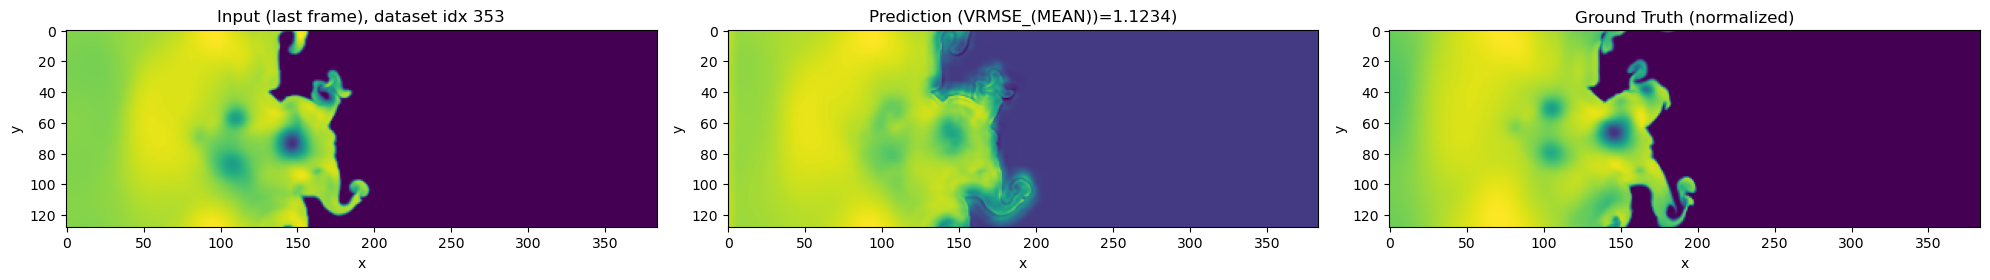

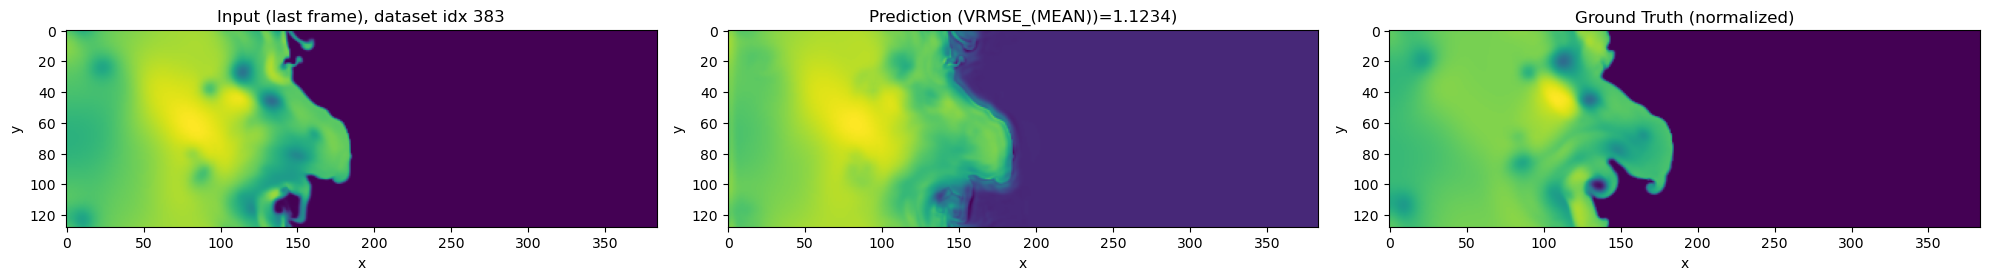

In [51]:
# Visualize a sample prediction with correct dataset alignment
n_frames=4
for i in [50,80]:
    # For test sample i, the corresponding dataset index is:
    dataset_idx = Ntrain + i + n_frames - 1
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
    # Show the last input frame (the 4th frame in the window)
    input_last_frame = X_test[i][-4:][0].numpy()  # channel 0 of last frame
    axes[0].imshow(input_last_frame)
    axes[0].set_title(f'Input (last frame), dataset idx {dataset_idx}')
   
    # Show the normalized ground truth used for training
    axes[2].imshow(y_test[i][0].numpy())
    axes[2].set_title('Ground Truth (normalized)')
    # Show the model prediction
    axes[1].imshow(test_pred[i, 0].numpy())
    axes[1].set_title(f'Prediction (VRMSE_(MEAN))={np.mean(vrmse_vals):.4f})')
    for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()

After implementing gradient loss, changing the kernel size from 3 -> 5 (second nearest neigbor), increasing the channels from 1 to 4 (So that all fields amplitude is captured in every pixel), increase the number of frames that go into each training set from 4 - 1 and introducing extra loss terms from edge recognition, we find that significant improvements in VRMSE. However, the model still diffuses out or replicates the input cells and doesn't make an expressive and physical prediction. Let's compare these results with the baseline model: the same CNN but without cyclic padding to enforce the translational equivariance in the y-direction:

In [ ]:
# --- Regular (zero) padding conv layer ---
class ZeroPadConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, padding=kernel_size // 2)

    def forward(self, x):
        return self.conv(x)

# --- Shared architecture, swappable padding ---
class PaddingTestCNN(nn.Module):
    def __init__(self, conv_class, in_ch=16, out_ch=4):
        super().__init__()
        kernel_s = 5
        self.conv1 = conv_class(in_ch, 32, kernel_size=kernel_s)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = conv_class(32, 64, kernel_size=kernel_s)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = conv_class(64, 32, kernel_size=kernel_s)
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = conv_class(32, 16, kernel_size=kernel_s)
        self.bn4 = nn.BatchNorm2d(16)
        self.conv5 = conv_class(16, out_ch, kernel_size=kernel_s)

    def forward(self, x):
        last_frame = x[:, -4:, :, :]
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        correction = self.conv5(x)
        return last_frame + correction

# --- Training function (identical for both) ---
def train_and_evaluate(model_name, model, n_epochs=50):
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    criterion = nn.MSELoss()

    train_dataset = TensorDataset(X_train_c, y_train_c)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            loss = criterion(pred, yb) + 0.1 * gradient_loss(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.size(0)
        epoch_loss /= len(train_dataset)
        scheduler.step(epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1}/{n_epochs}  Loss: {epoch_loss:.6f}')

    model.eval()
    with torch.no_grad():
        preds = []
        for i in range(0, len(X_test_c), 8):
            xb = X_test_c[i:i+8].to(device)
            preds.append(model(xb).cpu())
        test_pred = torch.cat(preds)

    test_pred_phys = test_pred * output_std + output_mean
    y_test_phys = y_test_c * output_std + output_mean

    field_names = ['Density', 'Pressure', 'Velocity_x', 'Velocity_y']
    vrmse_vals = []
    print(f'\n{model_name} — Per-field VRMSE:')
    for f in range(4):
        field_var = y_test_phys[:, f].var()
        field_mse = (test_pred_phys[:, f] - y_test_phys[:, f]).pow(2).mean()
        vrmse = (field_mse / field_var).sqrt()
        vrmse_vals.append(vrmse.item())
        print(f'  {field_names[f]:12s}: {vrmse:.4f}')
    avg = np.mean(vrmse_vals)
    print(f'  Average VRMSE: {avg:.4f}')
    return avg, test_pred_phys

# Run both
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_epochs = 50

print("=" * 50)
print("CIRCULAR PADDING (periodic in y)")
print("=" * 50)
model_circ = PaddingTestCNN(CircPadConv2d).to(device)
avg_circ, pred_circ = train_and_evaluate("Circular Padding", model_circ, n_epochs)

print("\n" + "=" * 50)
print("ZERO PADDING (standard)")
print("=" * 50)
model_zero = PaddingTestCNN(ZeroPadConv2d).to(device)
avg_zero, pred_zero = train_and_evaluate("Zero Padding", model_zero, n_epochs)

print("\n" + "=" * 50)
print(f"SUMMARY")
print(f"  Circular padding VRMSE: {avg_circ:.4f}")
print(f"  Zero padding VRMSE:     {avg_zero:.4f}")
print(f"  Difference:             {avg_zero - avg_circ:.4f}")
print("=" * 50)

CIRCULAR PADDING (periodic in y)
  Epoch 10/50  Loss: 19.956465
  Epoch 20/50  Loss: 17.845321
  Epoch 30/50  Loss: 16.705669
  Epoch 40/50  Loss: 15.966036
  Epoch 50/50  Loss: 15.179271

Circular Padding — Per-field VRMSE:
  Density     : 0.1884
  Pressure    : 0.8432
  Velocity_x  : 0.7288
  Velocity_y  : 0.5873
  Average VRMSE: 0.5869

ZERO PADDING (standard)
  Epoch 10/50  Loss: 20.313084
  Epoch 20/50  Loss: 18.323872
  Epoch 30/50  Loss: 17.123587
  Epoch 40/50  Loss: 16.531224
  Epoch 50/50  Loss: 15.769038

Zero Padding — Per-field VRMSE:
  Density     : 0.1947
  Pressure    : 0.8156
  Velocity_x  : 0.6942
  Velocity_y  : 0.6352
  Average VRMSE: 0.5849

SUMMARY
  Circular padding VRMSE: 0.5869
  Zero padding VRMSE:     0.5849
  Difference:             -0.0020 (zero wins)


# Part 3c and d
We find, as expected, that the regular CNN achieves the same performance as the one with cyclic padding (We take a difference of 0.002 in VRMSE to be negligible). If the model is not able to express the physics in the system, it wouldn't make sense that it would have an impact on the performance if we turn the symmetry-preserving constraint on or off. After trying a suite of tricks and methods to achieve a more expressive model we try one final thing: Use the Fourier Neural Operator that is used in the_well tutorial:

In [ ]:
from neuralop.models import FNO
# FNO: 
# --- Lightweight Model ---
class ResidualFNO(nn.Module):
    def __init__(self):
        super().__init__()
        self.fno = FNO(
            n_modes=(8, 8),       # fewer modes
            in_channels=16,
            out_channels=4,
            hidden_channels=64,   # small
            n_layers=10,           # fewer layers
            domain_padding=0.0,   # skip padding overhead
        )

    def forward(self, x):
        last_frame = x[:, -4:, :, :]
        correction = self.fno(x)
        return last_frame + correction

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_fno = ResidualFNO().to(device)
print(f"FNO parameters: {sum(p.numel() for p in model_fno.parameters()):,}")

# --- Training setup ---
optimizer = torch.optim.Adam(model_fno.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train_dataset = TensorDataset(X_train_c, y_train_c)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# --- Training loop (fewer epochs, no gradient loss) ---
n_epochs = 10
for epoch in range(n_epochs):
    model_fno.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model_fno(xb)
        loss = criterion(pred, yb)  # just MSE, skip gradient_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_dataset)

    if (epoch + 1) % 1 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}  Train loss: {epoch_loss:.6f}')

# --- Final evaluation ---
model_fno.eval()
with torch.no_grad():
    preds = []
    for i in range(0, len(X_test_c), 8):
        xb = X_test_c[i:i+8].to(device)
        preds.append(model_fno(xb).cpu())
    test_pred_fno = torch.cat(preds)
    test_mse_fno = criterion(test_pred_fno, y_test_c).item()

# Denormalize
test_pred_fno_phys = test_pred_fno * output_std + output_mean
y_test_phys = y_test_c * output_std + output_mean

print(f'\n--- FNO Results ---')
print(f'Test MSE (normalized): {test_mse_fno:.6f}')

print(f'\nPer-field VRMSE:')
for f in range(4):
    field_var = y_test_phys[:, f].var()
    field_mse = (test_pred_fno_phys[:, f] - y_test_phys[:, f]).pow(2).mean()
    vrmse = (field_mse / field_var).sqrt()
    print(f'  Field {f}: {vrmse:.4f}')


###
# Evaluate and print per-field VRMSE
model.eval()
with torch.no_grad():
    preds = []
    for i in range(0, len(X_test_c), 8):
        xb = X_test_c[i:i+8].to(device)
        preds.append(model(xb).cpu())
    test_pred = torch.cat(preds)

# Denormalize
test_pred_phys = test_pred * output_std + output_mean
y_test_phys = y_test_c * output_std + output_mean

field_names = ['Density', 'Pressure', 'Velocity_x', 'Velocity_y']
vrmse_vals = []

print('\nPer-field VRMSE (< 1.0 means better than predicting the mean):')
for f in range(4):
    field_var = y_test_phys[:, f].var()
    field_mse = (test_pred_phys[:, f] - y_test_phys[:, f]).pow(2).mean()
    vrmse = (field_mse / field_var).sqrt()
    vrmse_vals.append(vrmse.item())
    print(f'  {field_names[f]:12s}: {vrmse:.4f}')

print(f'\n  Average VRMSE: {np.mean(vrmse_vals):.4f}')

FNO parameters: 1,742,084
Epoch 1/10  Train loss: 27.122758
Epoch 2/10  Train loss: 20.961135
Epoch 3/10  Train loss: 18.951702
Epoch 4/10  Train loss: 17.969402
Epoch 5/10  Train loss: 16.930196
Epoch 6/10  Train loss: 16.099994
Epoch 7/10  Train loss: 15.406043
Epoch 8/10  Train loss: 14.516662
Epoch 9/10  Train loss: 13.776805


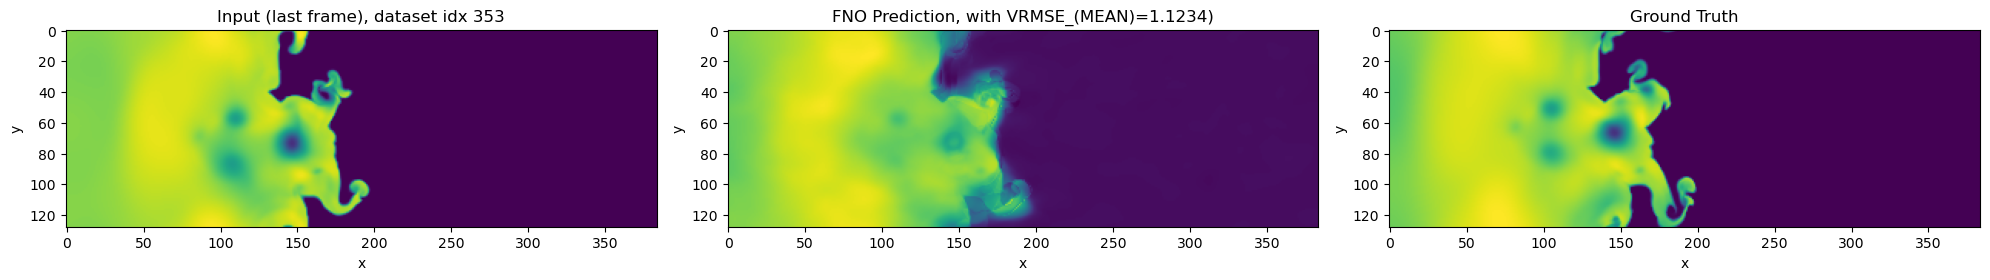

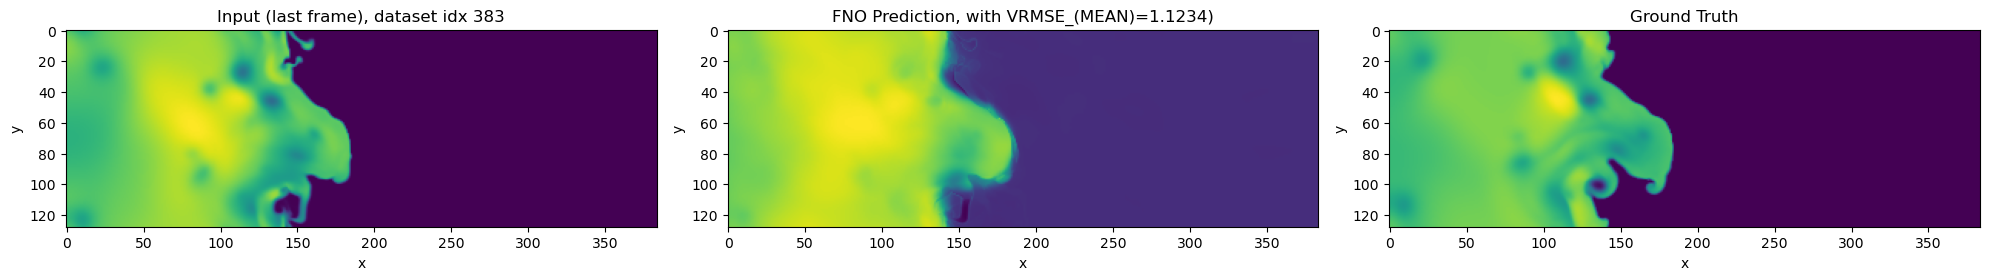

In [52]:
# Visualize FNO predictions (denormalized to physical units)
n_frames = 4
Ntrain = 300  # adjust to match your setup

for i in [50,80]:
    dataset_idx = Ntrain + i + n_frames - 1
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))

    # Last input frame (physical units) — channel 0 (density)
    input_last_frame = X_test[i][-4:][0].numpy()
    axes[0].imshow(input_last_frame)
    axes[0].set_title(f'Input (last frame), dataset idx {dataset_idx}')

    # FNO prediction (denormalized)
    axes[1].imshow(test_pred_fno_phys[i, 0].numpy())
    axes[1].set_title(f'FNO Prediction, with VRMSE_(MEAN)={np.mean(vrmse_vals):.4f})')

    # Ground truth (denormalized)
    axes[2].imshow(y_test_phys[i, 0].numpy())
    axes[2].set_title('Ground Truth')

    for ax in axes:
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()

We find that even for the baseline FNO-model with a larger number of parameters, we unfortunately fail to predict the physics well. 